---

CSC 672 Midterm

Title: Cloud-Based Air Quality Machine Learning Pipeline and Model Evaluation on the UC Irvine Air Quality Dataset

Name: Brennen Cramp

Date: 10/6/2026

---

# Task 1: Verify your Google Cloud environment setup, including capturing proof of your active cloud notebook instance or billing credit balance.

### 1 - Active Cloud Notebook Instance:

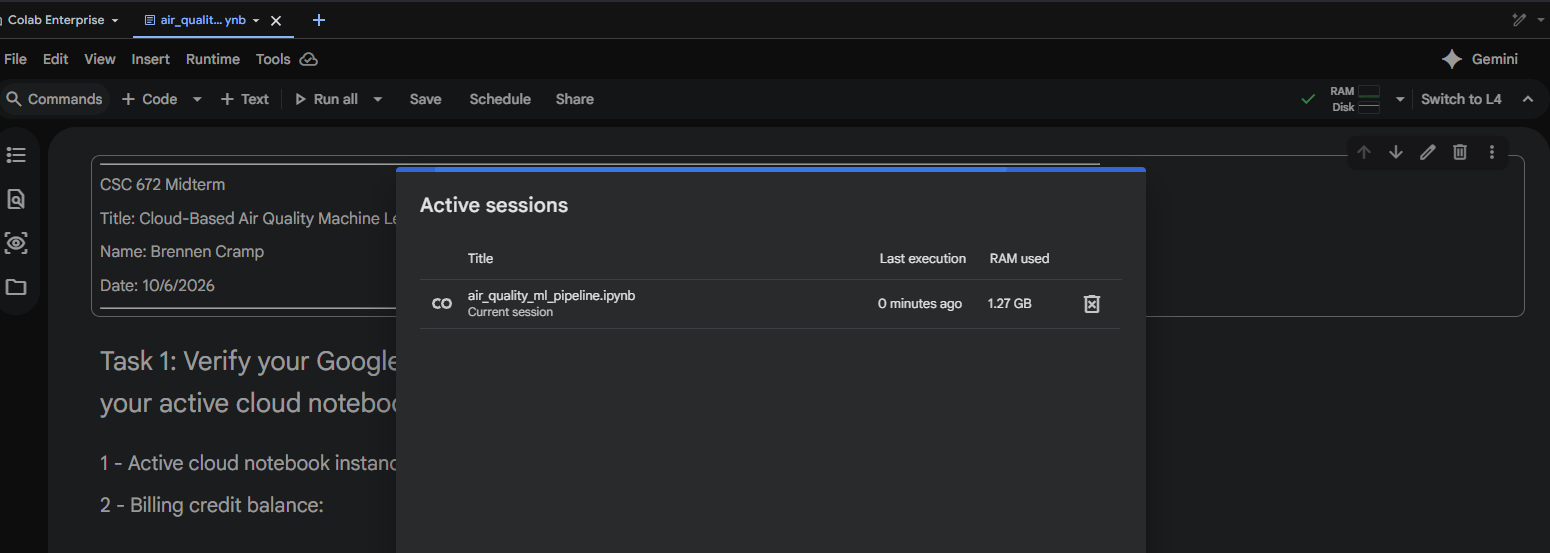

### 2 - Billing Credit Balance:

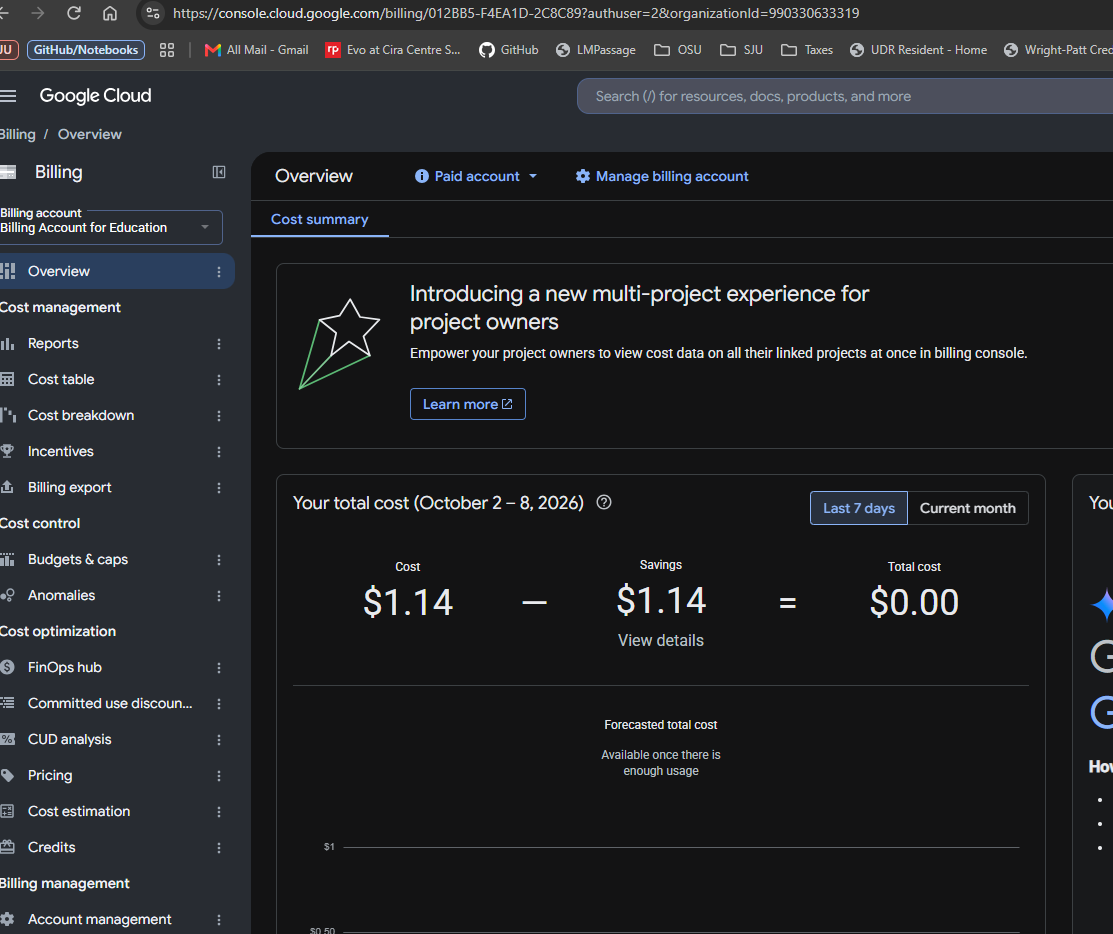

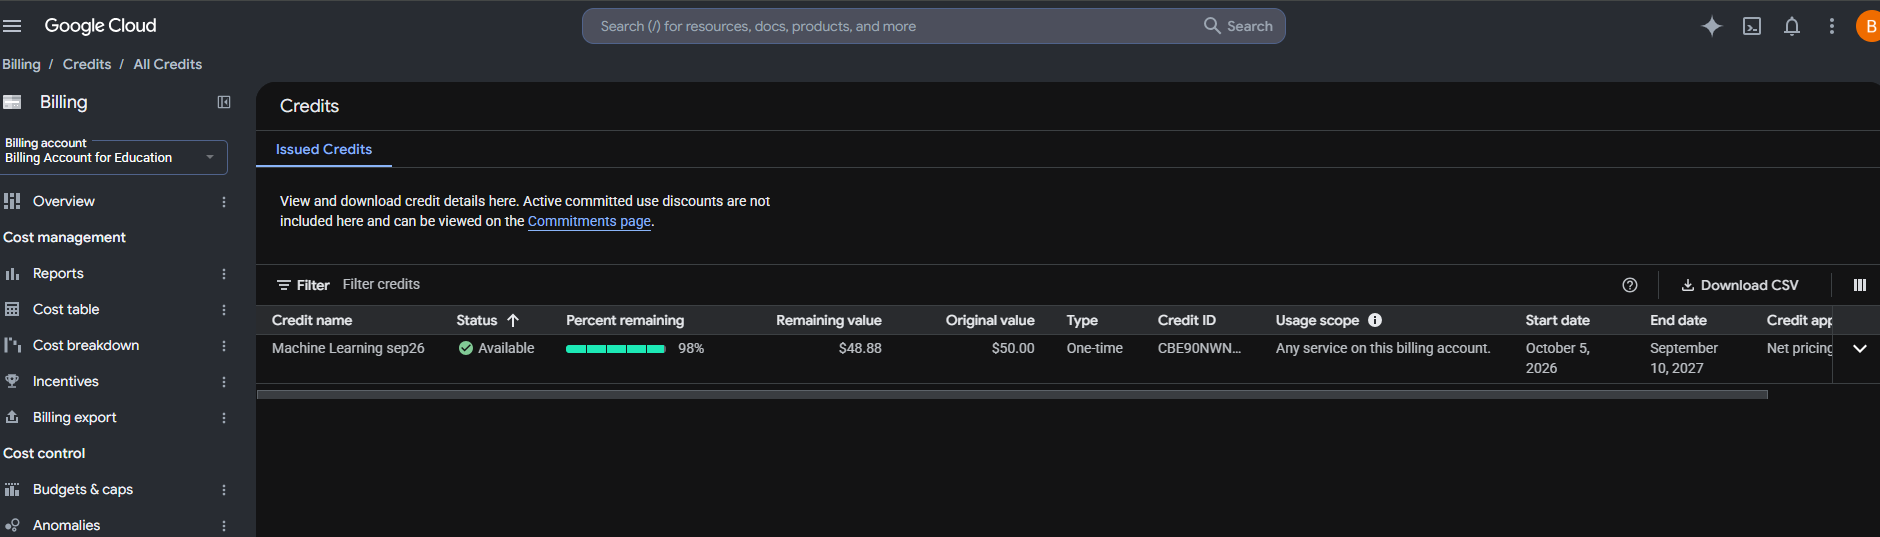

# Task 2: Load the dataset into a Pandas DataFrame

In [ ]:
# Task 2: Load the dataset into a Pandas DataFrame using the official ucimlrepo
# package or direct data retrieval methods linked to the UCI repository
# (https://archive.ics.uci.edu/dataset/360/air+qualityLinks to an external site).

# Import Pandas
import pandas as pd

# Import libraries to get just the .csv file from the .zip file
import urllib.request
import zipfile
import io

# Download the zip archive contents into memory
dataset_zip_url = "https://archive.ics.uci.edu/static/public/360/air+quality.zip"
req = urllib.request.Request(dataset_zip_url, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req) as response:
    zip_bytes = response.read()

# Extract the .zip file and pull ONLY the .csv file
with zipfile.ZipFile(io.BytesIO(zip_bytes)) as archive:
  with archive.open('AirQualityUCI.csv') as csv_file:
    # Load the dataset into a Pandas DataFrame
    # IMPORTANT: This set uses semicolon as a delimiter instead of commas, so I will set the
    # separator to be a semicolon here.
    df = pd.read_csv(csv_file, sep=';')

# Cleans up any trailing empty columns/rows that I saw were in the downloaded .csv file (lines 9359-9472)
df = df.dropna(how='all', axis=1)
df = df.dropna(how='all', axis=0)

# Task 3: Inspect and analyze features [multiple (7 total) code cells]

In [ ]:
# Task 3: Use structural inspection methods (head(), info(), describe()) to analyze the dataset structure and
# examine feature distributions across sensor and meteorological variables.
print("--- Task 3: Inspection ---")
print("\nFirst 5 rows of the dataset:")
df.head()

--- Task 3: Inspection ---

First 5 rows of the dataset:


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"


In [ ]:
print("General information about the Air Quality dataset:\n")
df.info()

print("\nSummary statistics of numerical columns:\n")
df.describe()

General information about the Air Quality dataset:

<class 'pandas.core.frame.DataFrame'>
Index: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   object 
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   object 
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   object 
 13  RH             9357 non-null   object 
 14  AH             9357 non-null   object 
dtypes: float64(8), object(7)
memory usage: 1.1+ MB

Summary statistics of numerical columns:



,PT08.S1(CO),NMHC(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3)
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,1048.990061,-159.090093,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032
std,329.832710,139.789093,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,921.000000,-200.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000
50%,1053.000000,-200.000000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000
75%,1221.000000,-200.000000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000
max,2040.000000,1189.000000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000


In [ ]:
# Get summary statistics for the CO(GT) column (contains categorical/object data types and is NOT numerical)
df['CO(GT)'].describe()

,CO(GT)
count,9357
unique,104
top,-200
freq,1592


In [ ]:
# Get summary statistics for the C6H6(GT) column (contains categorical/object data types and is NOT numerical)
df['C6H6(GT)'].describe()

,C6H6(GT)
count,9357
unique,408
top,"-200,0"
freq,366


In [ ]:
# Get summary statistics for the T column (contains categorical/object data types and is NOT numerical)
df['T'].describe()

,T
count,9357
unique,437
top,-200
freq,366


In [ ]:
# Get summary statistics for the RH column (contains categorical/object data types and is NOT numerical)
df['RH'].describe()

,RH
count,9357
unique,754
top,-200
freq,366


In [ ]:
# Get summary statistics for the AH column (contains categorical/object data types and is NOT numerical)
df['AH'].describe()

,AH
count,9357
unique,6684
top,-200
freq,366


# Task 4: Identify and handle implicit missing data values (such as the standard -200 sentinel values present in the air quality dataset) and implement a structured imputation strategy using Scikit-Learn's SimpleImputer.

In [ ]:
# Import Numpy and Scikit-Learn's SimpleImputer to handle missing entries
import numpy as np
from sklearn.impute import SimpleImputer

# Task 4.1: Quantify any missing or implicit missing values across the columns (such as the standard -200 sentinel
# values present in the air quality dataset).
print("--- Task 4.1: Quantify any missing or implicit missing values across the columns ---")

# Quantify missing values per column
print("\n--- Missing Value Counts ---")
print(df.isnull().sum())

# Replace all implicit -200 values with not a num (NaN)
# I will create a copy of the original dataframe to not overwrite the raw data
df_clean = df.copy()
df_clean = df_clean.replace(-200, np.nan)

# Checking for -200 strings for columns that are objects (including "," since C6H6(GT) showed "-200," as a top val)
df_clean = df_clean.replace('-200,0', np.nan)
df_clean = df_clean.replace('-200,', np.nan)
df_clean = df_clean.replace('-200', np.nan)

# Quantify missing values per column, again
print("\n--- New Missing Value Counts ---")
print(df_clean.isnull().sum())

# ----------------------------- 2nd Step -----------------------------
# Task 4.2: Implement/define a structured imputation strategy using Scikit-Learn's SimpleImputer.
print("--- Task 4.2: Implement/define a structured imputation strategy using Scikit-Learn's SimpleImputer ---")

# --- IMPORTANT NOTE: ---
# I will NOT use .fit_transform() during this step, on the training data, to avoid data leaks from my
# testing data into my training phase.

# Identify numeric and categorical columns/features in the dataframe
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# Next, I want to define the numeric columns using the median (instead of mean due to extreme outliers possibly skewing the mean)
print("Defining the imputer for the numeric columns using the median values per column.")
num_imputer = SimpleImputer(missing_values=np.nan, strategy='median')

# Additionally, I want to define the imputer for the categorical columns using the most occurring value
print("Defining the imputer for the categorical columns using the most occurring value per column.")
cat_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

print("Imputation strategies successfully defined!")

--- Task 4.1: Quantify any missing or implicit missing values across the columns ---

--- Missing Value Counts ---
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

--- New Missing Value Counts ---
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64
--- Task 4.2: Implement/define a structured imputation strategy using Scikit-Learn's SimpleImputer ---
Defining the imputer for the numeric columns using the median values per column.
Defining the imputer for t

# Task 5: Isolate numerical/categorical features and apply scaling (numeric) and encoding (categoric) to columns

In [ ]:
# Task 5: Isolate numerical and categorical features, then build a Scikit-Learn ColumnTransformer and Pipeline that applies
# appropriate scaling (StandardScaler or MinMaxScaler) to numerical columns and necessary encoding to categorical/temporal features.

# Import needed functionalities from Scikit-Learn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

print("--- Task 5: Isolate features and build preprocessing pipelines ---")


# -------------- Start of Data Cleanup Section --------------
# IMPORTANT: I got an error in a Task 6 since this data set uses commas as decimals!!!! SO, I will
# clean the data here before continuing, looping through all columns except Date and Time to clean up formats.
columns_to_clean = [col for col in df_clean.columns if col not in ['Date', 'Time']]

for col in columns_to_clean:
    if df_clean[col].dtype == 'object':
        # Replace commas with periods and cast to standard floats
        df_clean[col] = df_clean[col].astype(str).str.replace(',', '.')
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Explicitly ensure Date and Time are treated as categorical strings for select_dtypes
df_clean['Date'] = df_clean['Date'].astype(str)
df_clean['Time'] = df_clean['Time'].astype(str)
# -------------- End of Data Cleanup Section --------------


# Create features and target (y - C6H6(GT))
# I chose C6H6(GT) since after doing a Google search, Benzene is the 'most dangerous and toxic to human health'
features = df_clean[['Date', 'Time', 'PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']]
target = df_clean['C6H6(GT)']

# Separate numerical/categorical features from the features dataframe
num_features = features.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = features.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical features that will be scaled:", num_features)
print("Categorical features that will be encoded:", cat_features)

# Create individual pipeline for the numeric features using my median imputer from Task 4.2 and StandardScaler
num_transformer_standard = Pipeline(steps=[
    ('imputer', num_imputer),
    ('scaler', StandardScaler())
])

# Create individual pipeline for the numeric features using my median imputer from Task 4.2 and MinMaxScaler
num_transformer_min_max = Pipeline(steps=[
    ('imputer', num_imputer),
    ('scaler', MinMaxScaler())
])

# Create individual pipeline for the categorical features using my most fequent imputer from Task 4.2;
# I will also add the drop='first' parameter to avoid multicollinearity for SGDClassifier!
cat_transformer = Pipeline(steps=[
    ('imputer', cat_imputer),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False))
])

# Make the preprocessor with the StandardScaler for numerical features by combining the pipelines into a single ColumnTransformer
preprocessor_standard = ColumnTransformer(
    transformers=[
        ('num', num_transformer_standard, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

# Make the preprocessor with the MinMaxScalar for numerical features by combining the pipelines into a single ColumnTransformer
preprocessor_min_max = ColumnTransformer(
    transformers=[
        ('num', num_transformer_min_max, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

print("\nSuccessfully built both StandardScaler and MinMaxScaler preprocessor pipelines!")

--- Task 5: Isolate features and build preprocessing pipelines ---
Numerical features that will be scaled: ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
Categorical features that will be encoded: ['Date', 'Time']

Successfully built both StandardScaler and MinMaxScaler preprocessor pipelines!


# Task 6: Train classification models to predict air quality categories using standard logistic/softmax regression and an SGDClassifier configured with custom loss functions and hyperparameters, evaluating convergence speed and performance **[multiple (2 total) code cells]**

In [ ]:
# Task 6: Train classification models to predict air quality categories using standard
# logistic/softmax regression and an SGDClassifier configured with custom loss functions
# and hyperparameters, evaluating convergence speed and performance.

# Import needed functionalities from Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import classification_report, accuracy_score
import time

print("--- Task 6.1: Target Binning & Classification Model Training using StandardScaler ---")

# Cleanup by dropping any rows where the target is missing before I split or bin
valid_indices = target.dropna().index
features = features.loc[valid_indices]
target = target.loc[valid_indices]

# Splits the continuous data before applying qcut and I will use an 80/20 split (20% for test)
# and I will also set the random seed to be 100.
test_ratio = 0.2
seed = 100
X_train, X_test, y_train_cont, y_test_cont = train_test_split(
    features, target, test_size=test_ratio, random_state=seed
)

# -------------- Start of Target Binning Section --------------
# I will use quantile binning (pd.qcut) on the training set, splitting Benzene levels into:
# Class 0 (Low), Class 1 (Moderate), and Class 2 (High)
target_cats = ['Low', 'Moderate', 'High']
y_train, training_bins = pd.qcut(
    y_train_cont,
    q=3,
    labels=[0, 1, 2],
    retbins=True
)

# Modifies the outliers to infinity (-/+) which will make the test set handle values outside the training min/max
test_bins = training_bins.copy()
test_bins[0] = -np.inf
test_bins[-1] = np.inf

# Applies the training-derived bins to the test set using pd.cut
y_test = pd.cut(
    y_test_cont,
    bins=test_bins,
    labels=[0, 1, 2],
    include_lowest=True
)

print(f"Calculated training the edges of the bin: {training_bins}")
print("Training class distribution:\n", pd.Series(y_train).value_counts())
# -------------- End of Target Binning Section --------------

print(f"\n-------------------- Start of using StandardScaler --------------------")
X_train_scaled = preprocessor_standard.fit_transform(X_train)
X_test_scaled = preprocessor_standard.transform(X_test)

# -------- Setup for the first model: Softmax Regression --------
print("\n--- Training Logistic Regression (Softmax) ---")

# Force softmax by setting multi_class='multinomial' and the to control conv. attempts, I used max_iter = 1000
softmax_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=seed)

start_time = time.time()
softmax_reg.fit(X_train_scaled, y_train)
softmax_time = time.time() - start_time

y_pred_softmax = softmax_reg.predict(X_test_scaled)
print(f"Convergence/Training time: {softmax_time:.4f} seconds")
print(f"Softmax Accuracy: {accuracy_score(y_test, y_pred_softmax):.4f}")

# -------- Setup for the first model: SGD Classifier --------
print("\n--- Training SGDClassifier with Modified Huber Loss ---")

# For a smooth hinge loss variant to allow outlier influence, I used 'modified_huber' as the loss
# and max_iter/tol for conv. limits
sgd = SGDClassifier(loss='modified_huber', max_iter=2000, tol=1e-3, alpha=0.0001, random_state=seed)

start_time = time.time()
sgd.fit(X_train_scaled, y_train)
sgd_time = time.time() - start_time

y_pred_sgd = sgd.predict(X_test_scaled)
print(f"Convergence/Training time: {sgd_time:.4f} seconds")
print(f"SGD Classifier Accuracy: {accuracy_score(y_test, y_pred_sgd):.4f}")

# Performance eval reports section
print("\n---------------- Softmax Regression Report ----------------")
print(classification_report(y_test, y_pred_softmax, target_names=target_cats))
print("\n-----------------------------------------------------------")

print("\n------------------ SCG Classifier Report ------------------")
print(classification_report(y_test, y_pred_sgd, target_names=target_cats))
print("\n-----------------------------------------------------------")

print(f"\n-------------------- End of using StandardScaler --------------------")

--- Task 6.1: Target Binning & Classification Model Training using StandardScaler ---
Calculated training the edges of the bin: [ 0.1  5.7 11.6 63.7]
Training class distribution:
 C6H6(GT)
0    2443
2    2394
1    2355
Name: count, dtype: int64

-------------------- Start of using StandardScaler --------------------

--- Training Logistic Regression (Softmax) ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Convergence/Training time: 2.3351 seconds
Softmax Accuracy: 0.9755

--- Training SGDClassifier with Modified Huber Loss ---
Convergence/Training time: 0.8462 seconds
SGD Classifier Accuracy: 0.9739

---------------- Softmax Regression Report ----------------
              precision    recall  f1-score   support

         Low       0.98      0.98      0.98       632
    Moderate       0.95      0.97      0.96       566
        High       0.99      0.98      0.98       601

    accuracy                           0.98      1799
   macro avg       0.98      0.98      0.98      1799
weighted avg       0.98      0.98      0.98      1799


-----------------------------------------------------------

------------------ SCG Classifier Report ------------------
              precision    recall  f1-score   support

         Low       0.98      0.97      0.97       632
    Moderate       0.95      0.97      0.96       566
        High       0.99      0.99      0.99       601

    accuracy        

In [ ]:
print("--- Task 6.2: Classification Model Training using MinMaxScaler ---")

print(f"\n-------------------- Start of using MinMaxScaler --------------------")

X_train_minmax = preprocessor_min_max.fit_transform(X_train)
X_test_minmax = preprocessor_min_max.transform(X_test)

# -------- Setup for the first model: Softmax Regression --------
print("\n--- Training Logistic Regression (Softmax) with MinMaxScaler ---")

# Force softmax by setting multi_class='multinomial' and the to control conv. attempts, I used max_iter = 1000
softmax_reg_mm = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=seed)

start_time = time.time()
softmax_reg_mm.fit(X_train_minmax, y_train)
softmax_time_mm = time.time() - start_time

y_pred_softmax_mm = softmax_reg_mm.predict(X_test_minmax)
print(f"Convergence/Training time: {softmax_time_mm:.4f} seconds")
print(f"Softmax Accuracy: {accuracy_score(y_test, y_pred_softmax_mm):.4f}")

# -------- Setup for the second model: SGD Classifier --------
print("\n--- Training SGDClassifier with Modified Huber Loss with MinMaxScaler ---")

# For a smooth hinge loss variant to allow outlier influence, I used 'modified_huber' as the loss
# and max_iter/tol for conv. limits and alpha is set to 0.0001, using the same hyperparameters I used
# for the StandardScaler section!
sgd_mm = SGDClassifier(loss='modified_huber', max_iter=2000, tol=1e-3, alpha=0.0001, random_state=seed)

start_time = time.time()
sgd_mm.fit(X_train_minmax, y_train)
sgd_time_mm = time.time() - start_time

y_pred_sgd_mm = sgd_mm.predict(X_test_minmax)
print(f"Convergence/Training time: {sgd_time_mm:.4f} seconds")
print(f"SGD Classifier Accuracy: {accuracy_score(y_test, y_pred_sgd_mm):.4f}")

# Performance eval reports section
print("\n---------------- Softmax Regression Report (MinMaxScaler) ----------------")
print(classification_report(y_test, y_pred_softmax_mm, target_names=target_cats))
print("\n-------------------------------------------------------------------------")

print("\n------------------ SGD Classifier Report (MinMaxScaler) ------------------")
print(classification_report(y_test, y_pred_sgd_mm, target_names=target_cats))
print("\n-------------------------------------------------------------------------")

print(f"\n-------------------- End of using MinMaxScaler --------------------")

--- Task 6.2: Classification Model Training using MinMaxScaler ---

-------------------- Start of using MinMaxScaler --------------------

--- Training Logistic Regression (Softmax) with MinMaxScaler ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Convergence/Training time: 2.9884 seconds
Softmax Accuracy: 0.9255

--- Training SGDClassifier with Modified Huber Loss with MinMaxScaler ---
Convergence/Training time: 0.9671 seconds
SGD Classifier Accuracy: 0.9305

---------------- Softmax Regression Report (MinMaxScaler) ----------------
              precision    recall  f1-score   support

         Low       0.95      0.93      0.94       632
    Moderate       0.87      0.90      0.88       566
        High       0.96      0.95      0.95       601

    accuracy                           0.93      1799
   macro avg       0.92      0.92      0.92      1799
weighted avg       0.93      0.93      0.93      1799


-------------------------------------------------------------------------

------------------ SGD Classifier Report (MinMaxScaler) ------------------
              precision    recall  f1-score   support

         Low       0.93      0.95      0.94       632
    Moderate       0.91      0.87      0.89       566
        High 

# Task 7: Transition to regression tasks to predict continuous pollutant concentrations, implementing baseline Linear Regression alongside Ridge (L2) and Lasso (L1) regularization, and analyzing how the regularization parameter impacts feature coefficients and feature selection.

In [ ]:
# Task 7: Transition to regression tasks to predict continuous pollutant concentrations, implementing baseline
# Linear Regression alongside Ridge (L2) and Lasso (L1) regularization, and analyzing how the regularization
# parameter impacts feature coefficients and feature selection.

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

print("--- Task 7.1: Continuous Regression & Regularization Analysis (StandardScaler) ---")

# Fetch the orig feature names
feature_names = preprocessor_standard.get_feature_names_out()

# Setup the baseline linear regression for StandardScaler
print("\n--- Training Baseline Linear Regression for StandardScaler ---")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_cont)
y_pred_lr = lr_model.predict(X_test_scaled)
print(f"Linear Regression (StandardScaler) - RMSE: {np.sqrt(mean_squared_error(y_test_cont, y_pred_lr)):.4f}")
print(f"Linear Regression (StandardScaler) - R2-Score: {r2_score(y_test_cont, y_pred_lr):.4f}")

# Setup the ridge regression (L2) for StandardScaler
print("\n--- Training Ridge Regression (L2) for StandardScaler ---")

# I want to use a higher alpha to control the penalties to allow for more shrinkage
ridge_alpha = 10.0
ridge_model = Ridge(alpha=ridge_alpha, random_state=seed)
ridge_model.fit(X_train_scaled, y_train_cont)
y_pred_ridge = ridge_model.predict(X_test_scaled)
print(f"Ridge (alpha={ridge_alpha}) (StandardScaler) - RMSE: {np.sqrt(mean_squared_error(y_test_cont, y_pred_ridge)):.4f}")
print(f"Ridge (alpha={ridge_alpha}) (StandardScaler) - R2-Score: {r2_score(y_test_cont, y_pred_ridge):.4f}")

# Setup the lasso regression (L1) for StandardScaler
print("\n--- Training Lasso Regression (L1) for StandardScaler ---")

# I want to allow Lasso to completely zero-out less critical feature weights with a decent alpha and will
# use an increased max_iter so I can guarantee regularization conv
lasso_alpha = 0.1
lasso_model = Lasso(alpha=lasso_alpha, max_iter=5000, random_state=seed)
lasso_model.fit(X_train_scaled, y_train_cont)

y_pred_lasso = lasso_model.predict(X_test_scaled)
print(f"Lasso (alpha={lasso_alpha}) (StandardScaler) - RMSE: {np.sqrt(mean_squared_error(y_test_cont, y_pred_lasso)):.4f}")
print(f"Lasso (alpha={lasso_alpha}) (StandardScaler) - R2-Score: {r2_score(y_test_cont, y_pred_lasso):.4f}")

print("\n------------------ Feature Coefficient and Selction Analysis for StandardScaler ------------------")

# This will construct a DataFrame to easily view the weights side by side
coeff_scaled_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear Regression': lr_model.coef_,
    f'Ridge (L2, alpha={ridge_alpha})': ridge_model.coef_,
    f'Lasso (L1, alpha={lasso_alpha})': lasso_model.coef_
})

# Print coefficients sorted by their impact in baseline regression
print(coeff_scaled_df.sort_values(by='Linear Regression', key=abs, ascending=False).to_string(index=False))

# Calc feature exclusion numbers
zeroed_features_scaled = coeff_scaled_df[coeff_scaled_df[f'Lasso (L1, alpha={lasso_alpha})'] == 0]['Feature'].tolist()
print("\n----------------------------------------------------------------------")
print(f"Lasso Feature Selection for StandardScaler: {len(zeroed_features_scaled)} features were completely eliminated (coeff=0)")

if zeroed_features_scaled:
    print(f"Eliminated Features for StandardScaler: {zeroed_features_scaled}")

print("------------------------------------------------------------------------")

--- Task 7.1: Continuous Regression & Regularization Analysis (StandardScaler) ---

--- Training Baseline Linear Regression for StandardScaler ---
Linear Regression (StandardScaler) - RMSE: 0.7921
Linear Regression (StandardScaler) - R2-Score: 0.9891

--- Training Ridge Regression (L2) for StandardScaler ---
Ridge (alpha=10.0) (StandardScaler) - RMSE: 0.9760
Ridge (alpha=10.0) (StandardScaler) - R2-Score: 0.9834

--- Training Lasso Regression (L1) for StandardScaler ---
Lasso (alpha=0.1) (StandardScaler) - RMSE: 1.3545
Lasso (alpha=0.1) (StandardScaler) - R2-Score: 0.9681

------------------ Feature Coefficient and Selction Analysis for StandardScaler ------------------
             Feature  Linear Regression  Ridge (L2, alpha=10.0)  Lasso (L1, alpha=0.1)
cat__Date_10/03/2004          -7.314431               -1.160169              -0.000000
  num__PT08.S2(NMHC)           7.057850                8.114521               7.378563
cat__Date_01/12/2004          -7.023062               -2.429

In [ ]:
print("--- Task 7.2: Continuous Regression & Regularization Analysis (MinMaxScaler) ---")

# Fetch the orig feature names
feature_names = preprocessor_min_max.get_feature_names_out()

# Setup the baseline linear regression for MinMaxScaler
print("\n--- Training Baseline Linear Regression for MinMaxScaler ---")
lr_model_mm = LinearRegression()
lr_model_mm.fit(X_train_minmax, y_train_cont)
y_pred_lr_mm = lr_model_mm.predict(X_test_minmax)
print(f"Linear Regression (MinMaxScaler) - RMSE: {np.sqrt(mean_squared_error(y_test_cont, y_pred_lr_mm)):.4f}")
print(f"Linear Regression (MinMaxScaler) - R2-Score: {r2_score(y_test_cont, y_pred_lr_mm):.4f}")

# Setup the ridge regression (L2) for MinMaxScaler
print("\n--- Training Ridge Regression (L2) for MinMaxScaler ---")

# I will use the same alpha to see how MinMaxScaler impacts regularized weights
ridge_model_mm = Ridge(alpha=ridge_alpha, random_state=seed)
ridge_model_mm.fit(X_train_minmax, y_train_cont)
y_pred_ridge_mm = ridge_model_mm.predict(X_test_minmax)
print(f"Ridge (alpha={ridge_alpha}) (MinMaxScaler) - RMSE: {np.sqrt(mean_squared_error(y_test_cont, y_pred_ridge_mm)):.4f}")
print(f"Ridge (alpha={ridge_alpha}) (MinMaxScaler) - R2-Score: {r2_score(y_test_cont, y_pred_ridge_mm):.4f}")

# Setup the lasso regression (L1) for MinMaxScaler
print("\n--- Training Lasso Regression (L1) for MinMaxScaler ---")

lasso_model_mm = Lasso(alpha=lasso_alpha, max_iter=5000, random_state=seed)
lasso_model_mm.fit(X_train_minmax, y_train_cont)
y_pred_lasso_mm = lasso_model_mm.predict(X_test_minmax)
print(f"Lasso (alpha={lasso_alpha}) (MinMaxScaler) - RMSE: {np.sqrt(mean_squared_error(y_test_cont, y_pred_lasso_mm)):.4f}")
print(f"Lasso (alpha={lasso_alpha}) (MinMaxScaler) - R2-Score: {r2_score(y_test_cont, y_pred_lasso_mm):.4f}")

print("\n------------------ Feature Coefficient and Selection Analysis for MinMaxScaler ------------------")

# This will construct a DataFrame to easily view the weights side by side
coeff_minmax_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear Regression': lr_model_mm.coef_,
    f'Ridge (L2, alpha={ridge_alpha})': ridge_model_mm.coef_,
    f'Lasso (L1, alpha={lasso_alpha})': lasso_model_mm.coef_
})

# Print coefficients sorted by their impact in baseline regression
print(coeff_minmax_df.sort_values(by='Linear Regression', key=abs, ascending=False).to_string(index=False))

# Calc feature exclusion numbers
zeroed_features_minmax = coeff_minmax_df[coeff_minmax_df[f'Lasso (L1, alpha={lasso_alpha})'] == 0]['Feature'].tolist()
print("\n----------------------------------------------------------------------")
print(f"Lasso Feature Selection for MinMaxScaler: {len(zeroed_features_minmax)} features were completely eliminated (coeff=0)")

if zeroed_features_minmax:
    print(f"Eliminated Features for MinMaxScaler: {zeroed_features_minmax}")

print("------------------------------------------------------------------------")

--- Task 7.2: Continuous Regression & Regularization Analysis (MinMaxScaler) ---

--- Training Baseline Linear Regression for MinMaxScaler ---
Linear Regression (MinMaxScaler) - RMSE: 0.7921
Linear Regression (MinMaxScaler) - R2-Score: 0.9891

--- Training Ridge Regression (L2) for MinMaxScaler ---
Ridge (alpha=10.0) (MinMaxScaler) - RMSE: 1.3162
Ridge (alpha=10.0) (MinMaxScaler) - R2-Score: 0.9699

--- Training Lasso Regression (L1) for MinMaxScaler ---
Lasso (alpha=0.1) (MinMaxScaler) - RMSE: 1.6446
Lasso (alpha=0.1) (MinMaxScaler) - R2-Score: 0.9530

------------------ Feature Coefficient and Selection Analysis for MinMaxScaler ------------------
             Feature  Linear Regression  Ridge (L2, alpha=10.0)  Lasso (L1, alpha=0.1)
  num__PT08.S2(NMHC)          48.629236               24.687856              44.295489
   num__PT08.S4(NO2)          20.349469               11.867209               0.000000
   num__PT08.S3(NOx)          17.067154                1.637833              -0.0

# Task 8: Provide a final documentation cell or appendix section containing a screenshot or export of your Google Cloud billing or resource utilization dashboard showing active credit consumption.


### Billing Credit Balance:

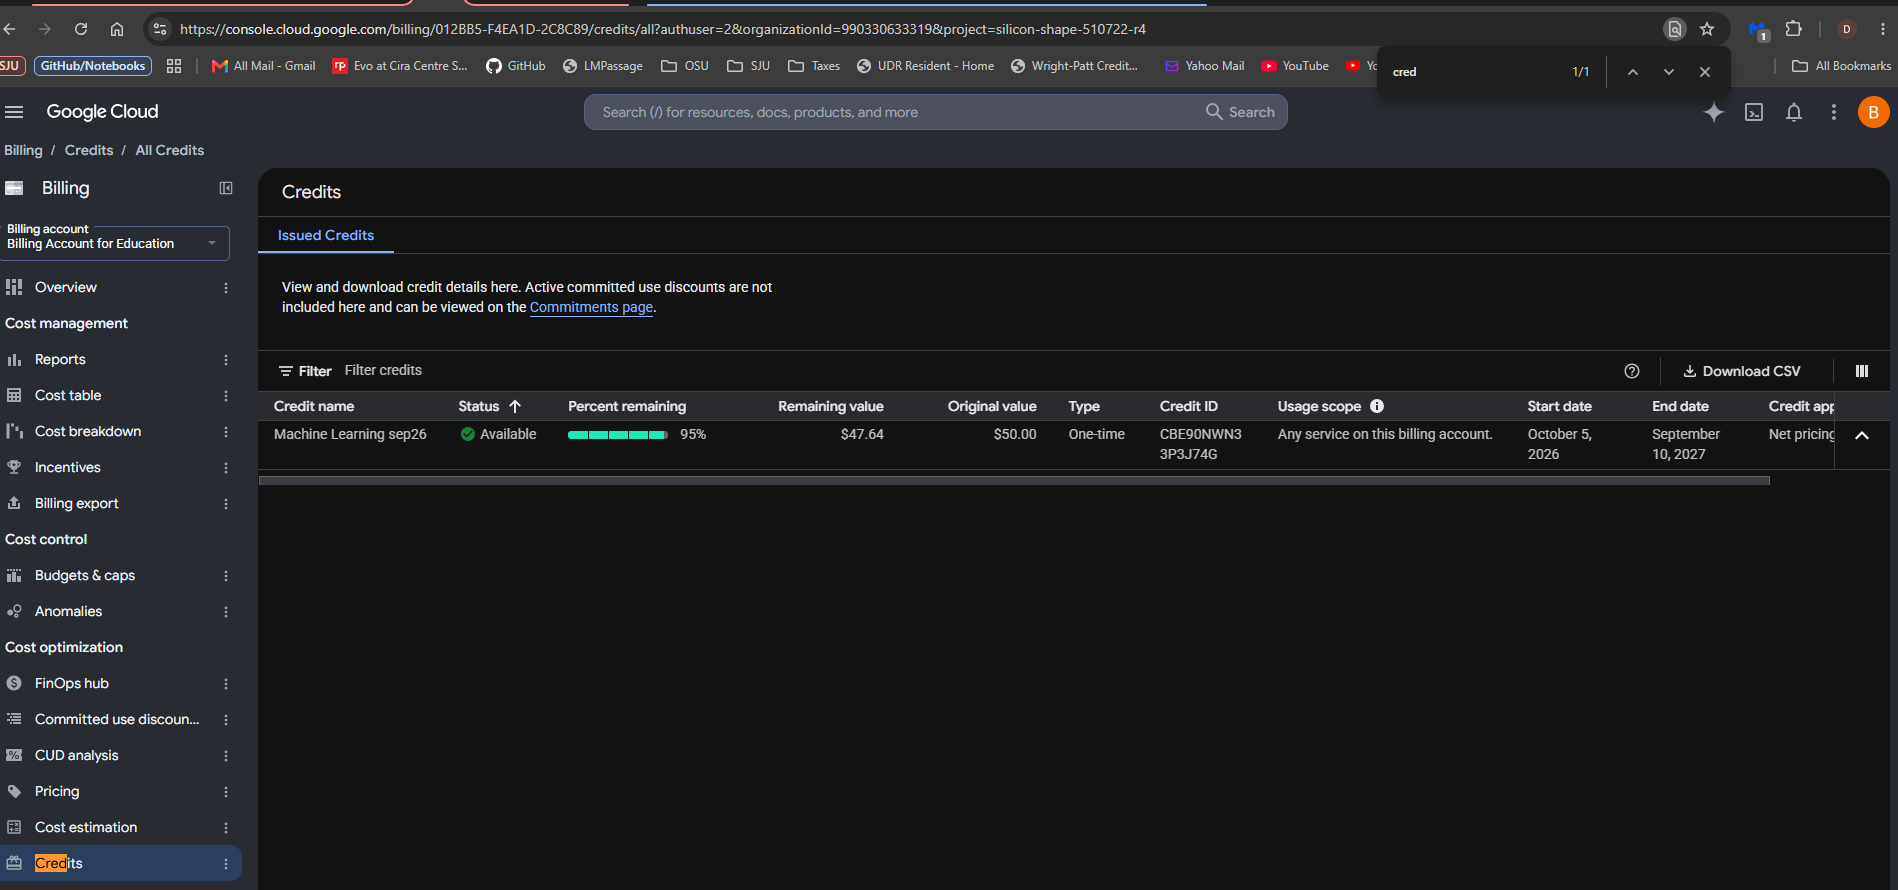

### Runtime Time Left:

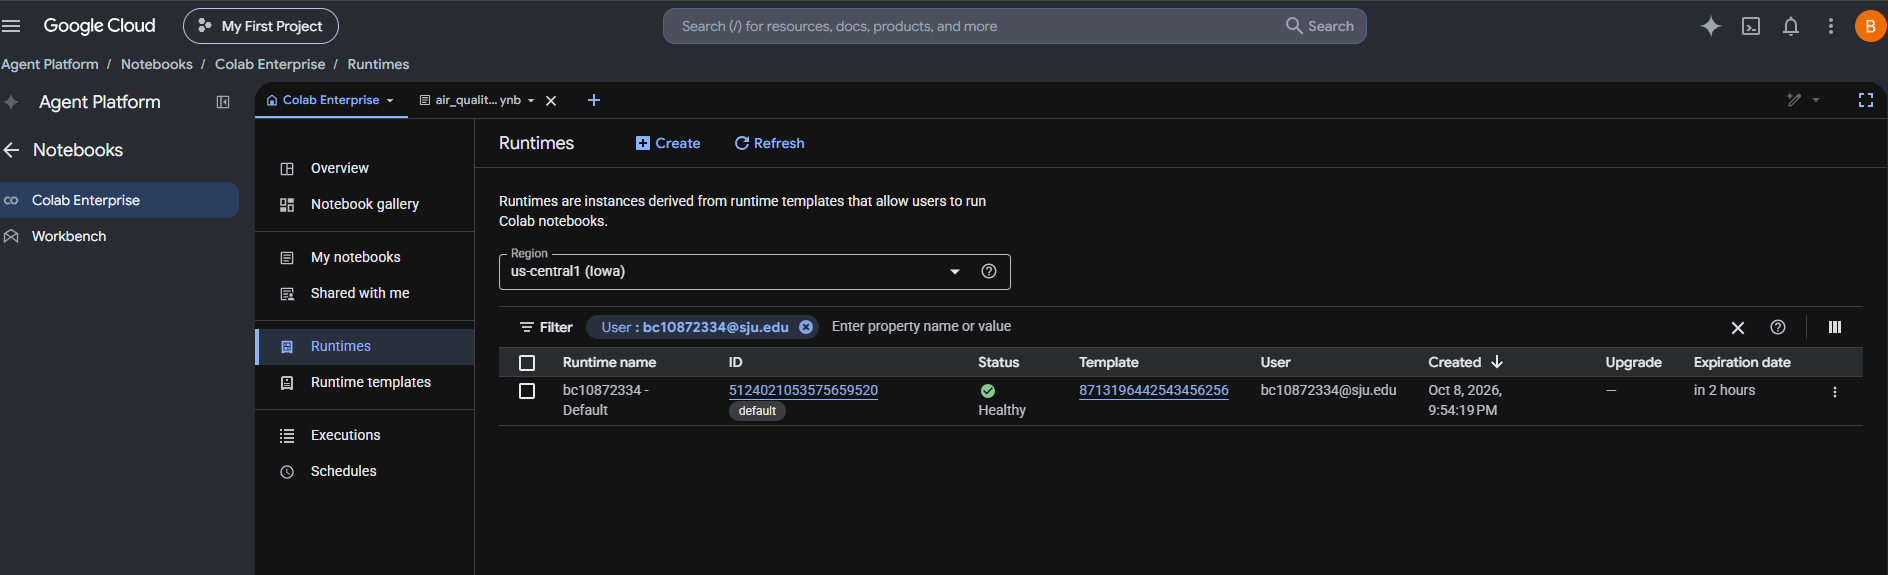